In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [2]:
df = pd.read_csv("salaries.csv")

In [3]:
df

,company,job,degree,salary_more_than_100k
0,amazon,project manager,bachelors,1
1,amazon,project manager,masters,1
2,amazon,sales executive,bachelors,0
3,amazon,sales executive,masters,0
4,amazon,programmer,bachelors,0
5,amazon,programmer,masters,1
6,jp morgan,sales executive,masters,0
7,jp morgan,programmer,bachelors,0
8,jp morgan,project manager,bachelors,0
9,jp morgan,project manager,masters,1


In [4]:
inputs = df.drop('salary_more_than_100k' , axis = 'columns')

In [5]:
target = df['salary_more_than_100k']

In [6]:
from sklearn.preprocessing import LabelEncoder

In [7]:
le = LabelEncoder()

In [9]:
inputs['company'] = le.fit_transform(inputs['company'])
inputs['job'] = le.fit_transform(inputs['job'])
inputs['degree'] = le.fit_transform(inputs['degree'])

In [10]:
inputs

,company,job,degree
0,0,1,0
1,0,1,1
2,0,2,0
3,0,2,1
4,0,0,0
5,0,0,1
6,1,2,1
7,1,0,0
8,1,1,0
9,1,1,1


In [11]:
from sklearn.tree import DecisionTreeClassifier

In [12]:
model = DecisionTreeClassifier()

In [13]:
model.fit(inputs , target)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [14]:
model.predict([[1,1,0]])

array([0], dtype=int64)

In [15]:
model.predict([[2,0,0]])

array([1], dtype=int64)

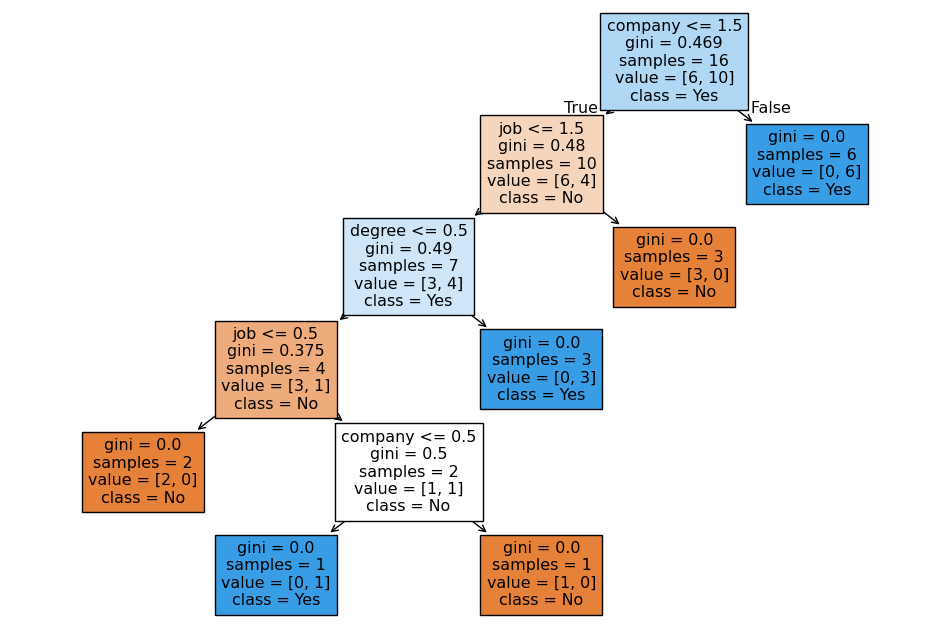

In [16]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(12,8))

plot_tree(
    model,
    feature_names=inputs.columns,   # column names
    class_names=['No', 'Yes'],      # target classes
    filled=True
)

plt.show()